In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import subprocess as sub
import time
from scipy.optimize import differential_evolution
from scipy.optimize import Bounds
from matplotlib import colors
#plt.style.use('seaborn-v0_8-whitegrid')
plt.style.use('default')
G = 6.6742e-8
C = 2.99792458e10
Msun = 1.9891e33

In [3]:
from sklearn.neighbors import NearestNeighbors

In [ ]:
N_spins = 12
N_dens = 20
r_ratios = np.log10(np.linspace(9.9, 6, N_spins))
eoss = np.array(pd.read_csv('../compose/max_dens.csv', header=None))
eos_names = eoss[:,0]
min_dens = eoss[:,1]
max_dens = eoss[:,2]

In [ ]:
class Eos_Set():

    def __init__(self, eos_name):

        self.name = eos_name
        self.data = np.load("star_data_"+eos_name+'.npy')
    
    def filter_index(self, i_r):

        massrange = np.array([0.9, 2.4])*Msun
        spinrange = 900*2*np.pi
        mrrange = np.array([0.05, 1])

        indices = np.where(
        (self.data[:, i_r, 3] > massrange[0]) & 
        (self.data[:, i_r, 3] < massrange[1]) & 
        (self.data[:, i_r, 1] < spinrange) & 
        (self.data[:, i_r, 4] > mrrange[0]) &
        (self.data[:, i_r, 4] < mrrange[1])
        )[0]
        indices = np.unique(indices)
        indices.sort()
        return indices.astype(int)
        
    def MR(self, i_r):

        return self.data[self.filter_index(i_r), i_r, 4]

    def SPN(self, i_r):

        return self.data[self.filter_index(i_r), i_r, 5]

    def z_rns(self, i_r):

        return self.data[self.filter_index(i_r), i_r, 6]

    def quad(self, i_r):

        return self.data[self.filter_index(i_r), i_r, 7]

    def J(self, i_r):

        return self.data[self.filter_index(i_r), i_r, 8]

In [ ]:
Eos_array = np.empty(eos_names.size, dtype=object)

for j in range(eos_names.size):

    Eos_array[j] = Eos_Set(eos_names[j])

Nreal = np.where(eos_names == 'Pol0')[0][0]
Eos_real = np.empty(Nreal, dtype=object)

for j in range(Nreal):

    Eos_real[j] = Eos_Set(eos_names[j])

Eos_poly = np.empty(10, dtype=object)

for j in range(10):

    Eos_poly[j] = Eos_Set(eos_names[j+Nreal])

In [ ]:
def N_nearest_err_q(Eos_array, k=10):

    M_R = np.empty([0])
    spins = np.empty([0])
    q_norm = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            spn = eos.SPN(i_r)
            q_norm_p = eos.quad(i_r)

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            q_norm = np.concatenate([q_norm, q_norm_p])

    q_norm = (q_norm-q_norm.max())/q_norm.min()

    X = np.column_stack((M_R, spins))
    neighbors = NearestNeighbors(n_neighbors=k).fit(X)

    dist, ind = neighbors.kneighbors(X)

    local_std = np.array([np.std(q_norm[i]) for i in ind])

    return np.mean(local_std)*100

In [ ]:
N_nearest_err_q(Eos_array, k=30)

0.9285638286020239

In [ ]:
def create_fit_func_q(shapes):

    def general_fit(M_R, spins, params):

        # m is for MR
        # n is for Omega

        params = np.array(params).reshape(shapes)
        n = shapes[0]
        m = shapes[1]

        fit = np.zeros(M_R.shape)
        for i in range(n):
            for j in range(m):
                #print(str(params[i,j])+" M/R^"+str(j+1)+" omega^"+str(2*(i+1)))
                fit += params[i,j]*M_R**(-j)*spins**(2*(i))
        
        return fit

    return general_fit

In [ ]:
def fractional_fit(M_R, spins, params):

    fit = np.zeros(M_R.shape)
    fit += params[0]
    fit += params[1]*M_R**params[2]
    fit += params[3]*spins**params[4]
    fit += params[5]*M_R**params[6]*spins**params[7]

    return fit

In [ ]:
def create_offset_fit(shapes):
    
    def offset_fit(M_R, spins, params):

        fit = np.zeros(M_R.shape)
        mr_off = params[0]

        params = np.array(params[1:]).reshape(shapes)
        n = shapes[0]
        m = shapes[1]

        fit = np.zeros(M_R.shape)
        for i in range(n):
            for j in range(m):
                #print(params[i,j], -j, 2*i)
                fit += params[i,j]*(M_R-mr_off)**(-(j))*spins**(2*(i))

        return fit

    return offset_fit

In [ ]:
def residual_objective_q(params, Eos_array, fit_func):

    M_R = np.empty([0])
    spins = np.empty([0])
    Js = np.empty([0])
    q_norm = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            spn = eos.SPN(i_r)
            j = eos.J(i_r)
            q_norm_p = eos.quad(i_r)

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            Js = np.concatenate([Js, j])
            q_norm = np.concatenate([q_norm, q_norm_p])

    q_emp = fit_func(M_R, spins, params)
    resid = np.sum((q_norm-q_emp)**2)

    return resid

In [ ]:
def LSQ_fit_q(Eos_array, shapes):

    M_R = np.empty([0])
    spins = np.empty([0])
    q_norm = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            spn = eos.SPN(i_r)
            q_norm_p = eos.quad(i_r)

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            q_norm = np.concatenate([q_norm, q_norm_p])

    n = shapes[0]
    m = shapes[1]

    X = ()
    for i in range(n):
        for j in range(m):
            X += ((M_R**(-j)*spins**(2*i)),)
    X = np.array(X).transpose()

    xT = np.transpose(X)
    xTx = np.dot(xT, X)
    xTxinv = np.linalg.inv(xTx)
    C = np.dot(xTxinv, xT)
    coefs = np.dot(C, q_norm)

    return coefs

In [ ]:
shape1 = [3,3]
params = LSQ_fit_q(Eos_real, shape1)
print(repr(params))
residual_objective_q(params, Eos_real, create_fit_func_q(shape1))

In [ ]:
def diff_optimize_fit_q(shapes, bounds, func):

    lb = [bounds[0]]
    ub = [bounds[1]]
    lbs = lb*shapes[0]*shapes[1]
    #lbs[0] = -50
    #lbs[1] = -1.1
    #lbs[2] = 1
    ubs = ub*shapes[0]*shapes[1]
    #ubs[0] = 0
    #ubs[1] = -1.1
    #ubs[2] = 5
    bounds = Bounds(lbs, ubs)
    result = differential_evolution(residual_objective_q, bounds, args=(Eos_array, func))

    coeffs = result.x.reshape(shapes)
    row_label = ['\u03A9^'+str(2*(i+1)) for i in range(shapes[0])]
    col_label = ['M/R^-'+str(i+1) for i in range(shapes[1])]
    table = pd.DataFrame(coeffs, index=row_label, columns=col_label)
    #print(table)

    print(residual_objective_q(result.x, Eos_array, func))

    return result.x

In [64]:
diff_optimize_fit_q([1,5], [-100,100], create_offset_fit([2,2]))

       M/R^-1    M/R^-2    M/R^-3    M/R^-4    M/R^-5
Ω^2  0.037773  0.108117 -0.023883  1.217719 -0.550469
39.804622652949924


array([ 0.03777341,  0.108117  , -0.02388278,  1.21771863, -0.55046857])

In [12]:
diff_optimize_fit_q([1,10], [-100,100], create_offset_fit([3,3]))

       M/R^-1     M/R^-2     M/R^-3     M/R^-4     M/R^-5     M/R^-6  \
Ω^2  1.326659 -44.678366 -99.787479 -55.579438 -65.895206 -99.997947   

        M/R^-7     M/R^-8    M/R^-9   M/R^-10  
Ω^2 -34.411055 -14.001854 -3.760905  20.63941  
84.59108308287419


array([  1.32665917, -44.67836575, -99.78747946, -55.57943776,
       -65.89520583, -99.99794699, -34.41105467, -14.00185438,
        -3.76090478,  20.63940965])

In [21]:
diff_optimize_fit_q([1,17], [-100,100], create_offset_fit([4,4]))

     M/R^-1    M/R^-2    M/R^-3     M/R^-4     M/R^-5   M/R^-6    M/R^-7  \
Ω^2   100.0 -0.025037 -1.603928 -28.798271 -41.325417 -2.64275 -5.278455   

       M/R^-8    M/R^-9   M/R^-10    M/R^-11    M/R^-12    M/R^-13  M/R^-14  \
Ω^2  8.863982  6.829274 -2.439321 -44.790818 -74.757536 -31.604986 -6.47308   

       M/R^-15    M/R^-16    M/R^-17  
Ω^2  26.847115 -22.167801  14.728383  
739.6611222871315


array([ 1.00000000e+02, -2.50369857e-02, -1.60392782e+00, -2.87982712e+01,
       -4.13254165e+01, -2.64274992e+00, -5.27845468e+00,  8.86398159e+00,
        6.82927385e+00, -2.43932112e+00, -4.47908181e+01, -7.47575362e+01,
       -3.16049860e+01, -6.47307956e+00,  2.68471147e+01, -2.21678011e+01,
        1.47283828e+01])

In [20]:
diff_optimize_fit_q([1,8], [-100,100], fractional_fit)

C:\Users\James\AppData\Local\Temp\ipykernel_10284\1107688192.py:24: RuntimeWarning: overflow encountered in square
  resid = np.sum((q_norm-q_emp)**2)
c:\Users\James\anaconda3\Lib\site-packages\numpy\core\_methods.py:239: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


       M/R^-1     M/R^-2    M/R^-3     M/R^-4    M/R^-5     M/R^-6    M/R^-7  \
Ω^2  0.280092 -19.423194  2.913112 -57.025638  1.167896  64.420147  0.095313   

      M/R^-8  
Ω^2  1.16251  
61.238745524010426


array([  0.28009222, -19.42319378,   2.9131121 , -57.02563778,
         1.16789637,  64.42014735,   0.095313  ,   1.16251014])

In [26]:
diff_optimize_fit_q([1,2], [-100,100], create_fit_func_q([1,2]))

      M/R^-1    M/R^-2
Ω^2  0.87003 -0.247205
746.4296724134347


array([ 0.87003036, -0.24720542])

In [25]:
diff_optimize_fit_q([1,3], [-100,100], create_fit_func_q([1,3]))

       M/R^-1    M/R^-2    M/R^-3
Ω^2 -0.118422  0.096369 -0.027196
705.6573228198397


array([-0.11842185,  0.09636865, -0.02719638])

In [24]:
diff_optimize_fit_q([2,2], [-100,100], create_fit_func_q([2,2]))

       M/R^-1    M/R^-2
Ω^2  0.095664 -0.030087
Ω^4  3.284887 -1.077868
47.21068119915218


array([ 0.09566357, -0.03008651,  3.28488749, -1.07786759])

In [19]:
diff_optimize_fit_q([2,3], [-100,100], create_fit_func_q([2,3]))

       M/R^-1    M/R^-2    M/R^-3
Ω^2 -0.142676  0.067551 -0.008801
Ω^4  1.627222 -0.636026 -0.026227
39.12059272173232


array([-0.14267624,  0.06755057, -0.00880137,  1.6272218 , -0.63602563,
       -0.02622712])

In [29]:
diff_optimize_fit_q([3,2], [-100,100], create_fit_func_q([3,2]))

       M/R^-1    M/R^-2
Ω^2 -0.012603  0.002684
Ω^4  4.705879 -1.578030
Ω^6 -2.459893  1.151079
33.9262432789763


array([-1.26029729e-02,  2.68393666e-03,  4.70587943e+00, -1.57802971e+00,
       -2.45989288e+00,  1.15107928e+00])

In [27]:
diff_optimize_fit_q([3,3], [-100,100], create_fit_func_q([3,3]))

       M/R^-1    M/R^-2    M/R^-3
Ω^2  0.022473 -0.009421  0.000781
Ω^4  0.453561  0.013021 -0.129964
Ω^6  1.975237 -1.150123  0.218770
26.34319298129181


array([ 2.24730636e-02, -9.42093080e-03,  7.81066484e-04,  4.53561409e-01,
        1.30210745e-02, -1.29963847e-01,  1.97523732e+00, -1.15012287e+00,
        2.18769967e-01])

In [95]:
diff_optimize_fit_q([4,3], [-100,100], create_fit_func_q([4,3]))

KeyboardInterrupt: 

In [ ]:
def plot_3dquads(Eos_array, fit_func, params, errors=False):

    fig = plt.figure(figsize=plt.figaspect(0.9)*2)
    ax = fig.add_subplot(projection='3d')

    M_R = np.empty([0])
    spins = np.empty([0])
    js = np.empty([0])
    q_norm = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            spn = eos.SPN(i_r)
            j = eos.J(i_r)
            q_norm_p = (eos.quad(i_r))
            q_emp_p = fit_func(mr, spn, params)

            if errors:
                ax.scatter(mr, spn**2, (q_norm_p-q_emp_p)/q_emp_p, alpha=0.3, s=5, c='k')
            else:
                ax.scatter(mr, spn**2, q_norm_p, alpha=0.3, s=5, c='k')

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            js = np.concatenate([js, j])
            q_norm = np.concatenate([q_norm, q_norm_p])

    M_R_mesh, spins_mesh = np.meshgrid(np.sort(M_R), np.sort(spins))
    q_emp = fit_func(M_R_mesh, spins_mesh, params)

    if errors:
        ax.plot_surface(M_R_mesh, spins_mesh**2, np.zeros(M_R_mesh.shape), color='green', alpha=0.2)
    else:
        ax.plot_surface(M_R_mesh, spins_mesh**2, q_emp, color='green', alpha=0.2)
    ax.view_init(elev=10, azim=90)
    ax.set_box_aspect(aspect=(1, 1, 1))
    font=11
    ax.tick_params(labelsize=font, pad=1)
    ax.tick_params(axis='z', labelsize=font, pad=4)
    ax.set_xlabel("M/R", labelpad=2)
    ax.set_ylabel("$\overline{\Omega}^{\ 2}$", labelpad=2)
    ax.set_zlabel("$q$", labelpad=8)
    #ax.set_zlim([-1, 1])

    #plt.savefig("3d_z.png", dpi=390)

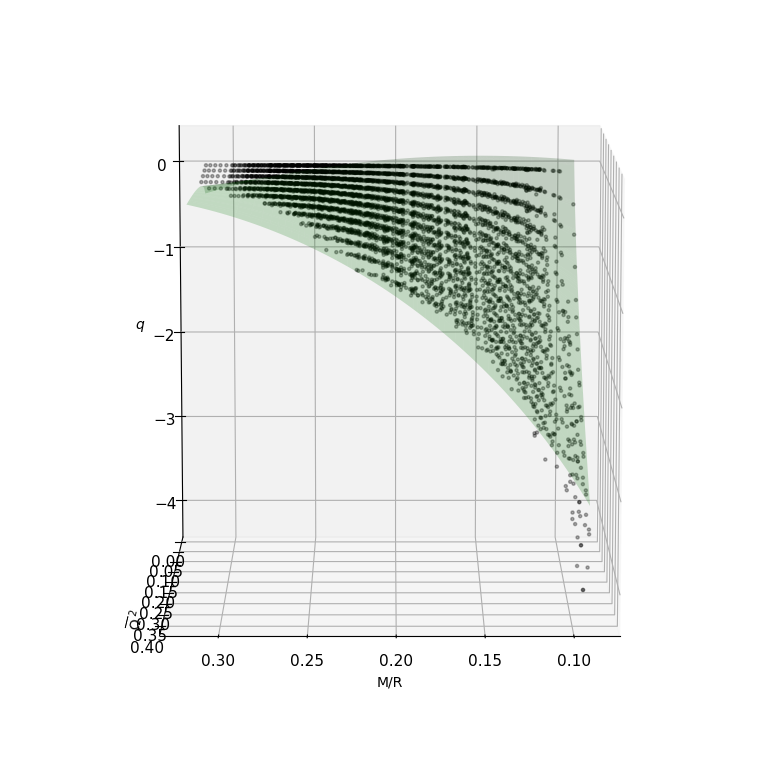

In [81]:
plot_3dquads(Eos_array, fractional_fit, [  0.28009222, -19.42319378,   2.9131121 , -57.02563778,
         1.16789637,  64.42014735,   0.095313  ,   1.16251014])

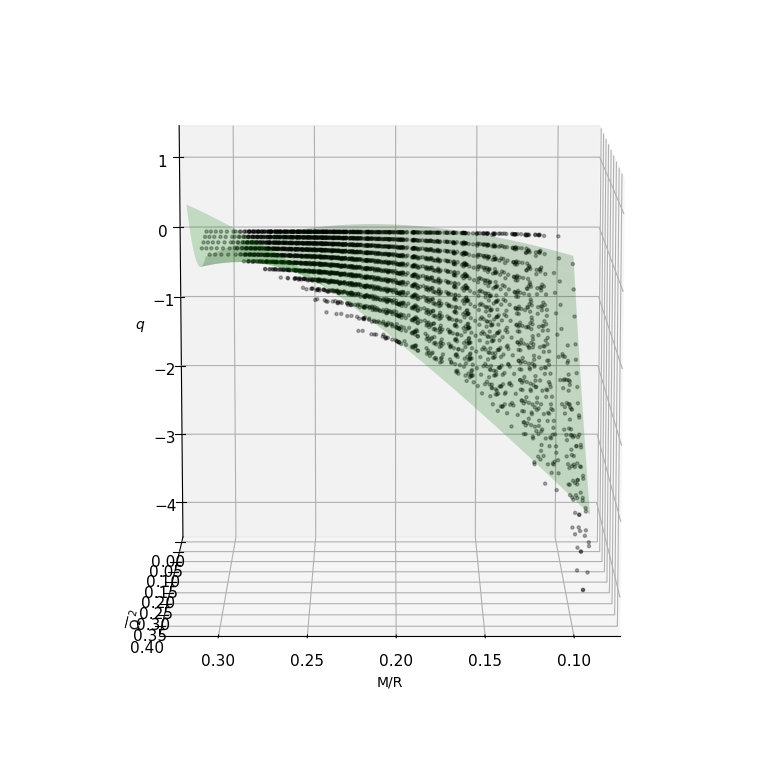

In [ ]:
plot_3dquads(Eos_array, create_offset_fit([3,3]), [  1.32665917, -44.67836575, -99.78747946, -55.57943776,
       -65.89520583, -99.99794699, -34.41105467, -14.00185438,
        -3.76090478,  20.63940965])

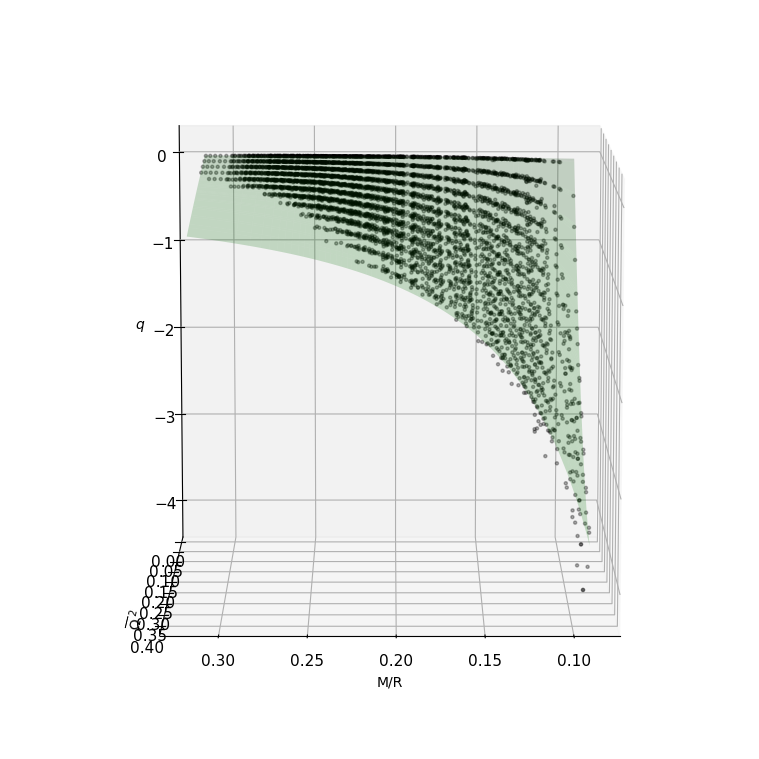

In [ ]:
plot_3dquads(Eos_array, create_fit_func_q([3,3]), [ 1.53943931e-02, -8.67180023e-03,  8.59192806e-04,  9.02834884e-01,
 -8.53436263e-02, -1.24947066e-01, -1.13128531e+00, -3.20641889e-01,
  1.69007890e-01])

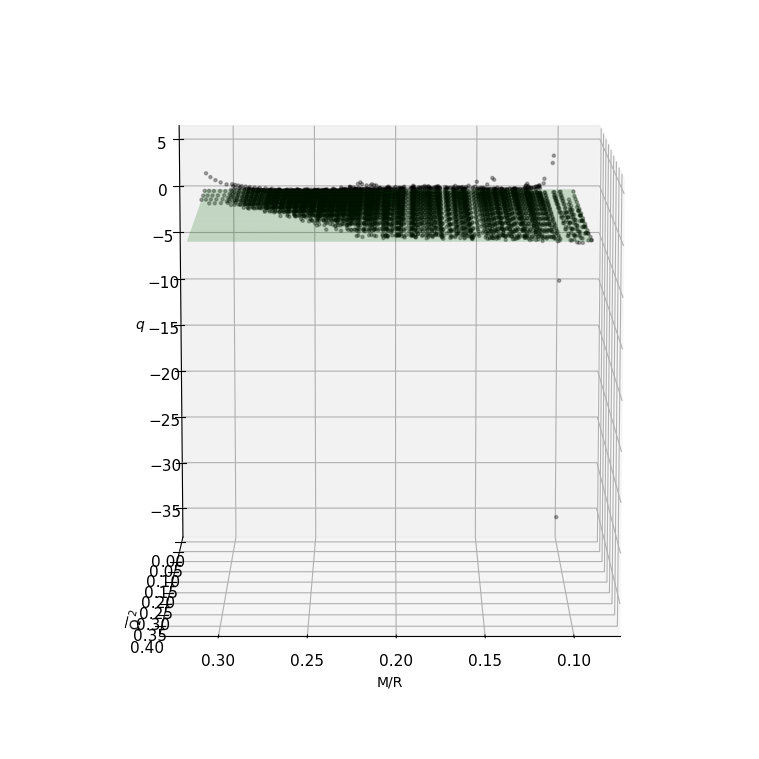

In [142]:
plot_3dquads(Eos_array, create_fit_func_q([5,5]), [ 4.37609962e-01, -3.38207137e-01,  9.38312602e-02, -1.11375115e-02,
  4.80919266e-04, -1.59758401e+01,  1.33258920e+01, -3.94224965e+00,
  4.60189824e-01, -2.01584060e-02,  5.40122705e+01, -6.01041770e+01,
  2.03301416e+01, -2.72240773e+00,  1.31881393e-01,  6.25889083e+01,
  7.50694205e+01, -4.37436260e+01,  7.11040840e+00, -3.82660242e-01,
 -6.33330037e+02,  2.01984196e+02, -4.19182089e+00, -3.65710930e+00,
  3.03919454e-01], True)

In [93]:
def plot_3dquads_J(Eos_array, fit_func, params):

    fig = plt.figure(figsize=plt.figaspect(0.9)*2)
    ax = fig.add_subplot(projection='3d')

    M_R = np.empty([0])
    spins = np.empty([0])
    js = np.empty([0])
    q_norm = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            spn = eos.SPN(i_r)
            j = eos.J(i_r)
            q_norm_p = (eos.quad(i_r))
            q_emp_p = fit_func(mr, spn, params)

            #ax.scatter(mr, spn**2, -q_norm_p/j**2+q_emp_p, alpha=0.3, s=5, c='k')
            #ax.scatter(mr, spn**2, q_norm_p, alpha=0.3, s=5, c='k')

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            js = np.concatenate([js, j])
            q_norm = np.concatenate([q_norm, q_norm_p])

    M_R_mesh, spins_mesh = np.meshgrid(np.sort(M_R), np.sort(spins))
    q_emp = fit_func(M_R_mesh, spins_mesh, params)

    ax.plot_surface(M_R_mesh, spins_mesh**2, q_emp, color='green', alpha=0.2)
    #ax.plot_surface(M_R_mesh, spins_mesh**2, np.zeros(M_R_mesh.shape), color='green', alpha=0.2)
    ax.view_init(elev=35, azim=-120)
    ax.set_box_aspect(aspect=(1, 1, 1))
    font=11
    ax.tick_params(labelsize=font, pad=1)
    ax.tick_params(axis='z', labelsize=font, pad=4)
    ax.set_xlabel("M/R", labelpad=2)
    ax.set_ylabel("$\overline{\Omega}^{\ 2}$", labelpad=2)
    ax.set_zlabel("$q$", labelpad=8)
    #ax.set_zlim([-1, 1])

    #plt.savefig("3d_z.png", dpi=390)

In [89]:
def PP_fit(M_R, spins, params):

    # m is for MR
    # n is for Omega

    params = np.array(params).reshape([6,6])
    n = 6
    m = 6

    fit = np.zeros(M_R.shape)
    for i in range(n):
        for j in range(m):
            #print(str(params[i,j])+" M/R^"+str(j+1)+" omega^"+str(2*(i+1)))
            fit += params[j,i]*M_R**(j)*(spins**2)**(i)
    
    return -fit

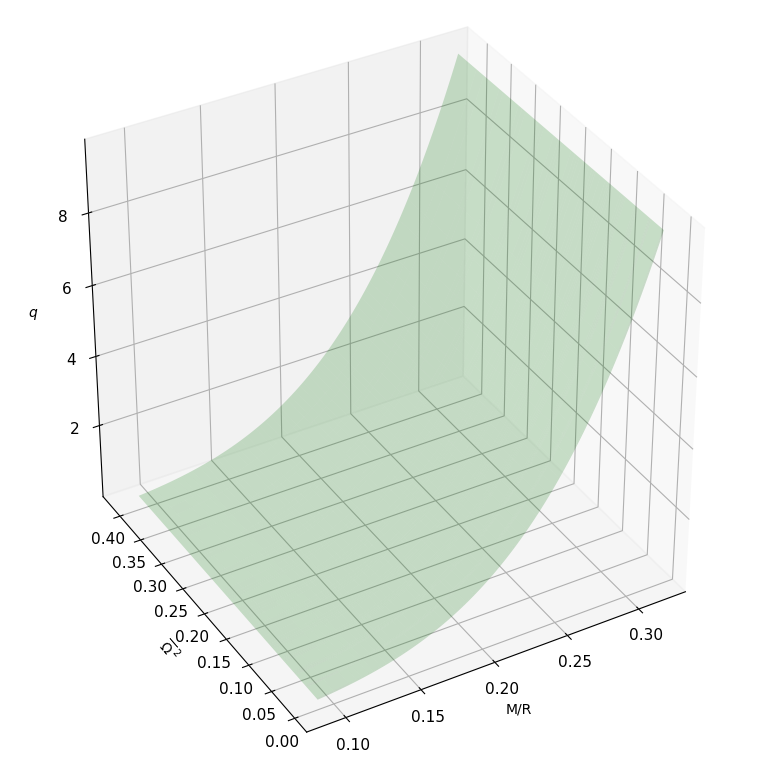

In [94]:
plot_3dquads_J(Eos_array, PP_fit, [  0.006802751, -0.0010699002, 0.0077681018, -0.00030342856, 0.00061273085, -0.00050058667, 
                                  -0.43993096,   0.050094955,  0.050094955,   0.0055645259, -0.0051861927,   0,
                                   0.27137482,  -0.022554846,  0.061857273,  -0.060425422,   0,              0,
                                  -0.10955132,   0.76965321,  -0.93568604,    0,             0,              0,
                                -961.5437,      -0.13503803,   0,             0,             0,              0,
                                   1.445554,     0,            0,             0,             0,              0])

In [ ]:
plot_3dquads(Eos_array, create_fit_func_q([2,2]), [-4.03414915,  0.4430781 , 10.        , -0.9522477 ])

In [ ]:
def old_formula(M_R, spins, params=[0.52, 1.15]):

    return 1/np.sqrt(1-2*M_R)*(1+spins**2*(params[1]*M_R**2+params[0]*M_R))-1

In [14]:
def create_fit_func(shapes):

    def general_fit(M_R, spins, params):

        # m is for MR
        # n is for Omega

        params = np.array(params).reshape(shapes)
        n = shapes[0]
        m = shapes[1]

        fit = np.ones(M_R.shape)
        for i in range(n):
            for j in range(m):
                #print(str(params[i,j])+" M/R^"+str(j+1)+" omega^"+str(2*(i+1)))
                fit += params[i,j]*M_R**(j+1)*spins**(2*(i+1))

        fit *= 1/np.sqrt(1-2*M_R)
        
        return fit-1

    return general_fit

In [15]:
def residual_objective(params, Eos_array, fit_func):

    M_R = np.empty([0])
    spins = np.empty([0])
    z_norm = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            spn = eos.SPN(i_r)
            z_norm_p = (eos.z_rns(i_r)+1)*np.sqrt(1-2*mr)-1

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            z_norm = np.concatenate([z_norm, z_norm_p])

    z_emp = (fit_func(M_R, spins, params)+1)*np.sqrt(1-2*M_R)-1
    resid = np.sum((z_norm-z_emp)**2)

    return resid

In [ ]:
def diff_optimize_fit(shapes, bounds):

    lb = [bounds[0]]
    ub = [bounds[1]]
    lbs = lb*shapes[0]*shapes[1]
    #lbs[0] = 0.5439611
    #lbs[1] = 1.00764174
    ubs = ub*shapes[0]*shapes[1]
    #ubs[0] = 0.5439611
    #ubs[1] = 1.00764174
    bounds = Bounds(lbs, ubs)
    result = differential_evolution(residual_objective, bounds, args=(Eos_array, create_fit_func(shapes)))

    coeffs = result.x.reshape(shapes)
    row_label = ['\u03A9^'+str(2*(i+1)) for i in range(shapes[0])]
    col_label = ['M/R^'+str(i+1) for i in range(shapes[1])]
    table = pd.DataFrame(coeffs, index=row_label, columns=col_label)
    print(table)

    print(residual_objective(result.x, Eos_array, create_fit_func(shapes)))


    return result.x

In [17]:
for eos in Eos_array:

    for i in range(N_spins):

        mr = eos.MR(i)
        js = eos.SPN(i)
        Zr = eos.z_rns(i)
        Ze = create_fit_func([2,2])(mr, js, [0.60038789,  0.6157292 ,  -0.19602428,  1.40895649])

        bad_k = np.where(np.abs(Zr-Ze) > 0.0009)[0]

        if (bad_k.size > 0):

            for k in bad_k:
            
                print(eos.name)
                print('M = '+str(eos.data[k, i, 3]/Msun)+' Msun')
                print('R = '+str(eos.data[k, i, 2]/100000)+' km')
                print('\u03A9 = '+str(eos.data[k, i, 1]/(2*np.pi))+' Hz')
                print('r = '+str(r_ratios[i])+'\n')


APR
M = 2.168601992431744 Msun
R = 10.43553689143 km
Ω = 461.5203230893851 Hz
r = 0.979796613911713

KDE0v
M = 1.980385823678749 Msun
R = 9.85385782054 km
Ω = 801.2461275409757 Hz
r = 0.9462735797680495

Pol8
M = 2.2485927663090606 Msun
R = 11.03487786818 km
Ω = 811.7606776887344 Hz
r = 0.928488958588275



In [18]:
diff_optimize_fit([1,2], [-2,2])

        M/R^1     M/R^2
Ω^2  0.567581  0.874525


array([0.56758113, 0.87452545])

In [28]:
diff_optimize_fit([1,3], [-5,5])

       M/R^1     M/R^2     M/R^3
Ω^2  0.47294  1.898759 -2.622659


array([ 0.4729402 ,  1.89875872, -2.62265946])

In [22]:
diff_optimize_fit([2,2], [-2,2])

        M/R^1     M/R^2
Ω^2  0.596598  0.633946
Ω^4 -0.200577  1.463362


array([ 0.59659782,  0.63394646, -0.20057686,  1.46336219])

In [23]:
diff_optimize_fit([2,3], [-2,2])

        M/R^1     M/R^2     M/R^3
Ω^2  0.544469  1.145648 -1.173350
Ω^4 -0.089276  0.472594  1.937668


array([ 0.54446865,  1.14564791, -1.17334963, -0.08927648,  0.47259355,
        1.93766783])

In [24]:
diff_optimize_fit([2,4], [-2,2])

        M/R^1     M/R^2     M/R^3     M/R^4
Ω^2  0.541895  1.169560 -1.274617  0.218256
Ω^4 -0.085546  0.483082  1.801846 -0.040830


array([ 0.54189483,  1.16955994, -1.27461703,  0.21825643, -0.08554595,
        0.48308175,  1.80184567, -0.04083036])

In [25]:
diff_optimize_fit([3,2], [-2,2])

        M/R^1     M/R^2
Ω^2  0.609495  0.579658
Ω^4 -0.321310  1.979435
Ω^6  0.243513 -1.050092


array([ 0.60949465,  0.57965814, -0.32130987,  1.9794347 ,  0.24351267,
       -1.05009229])

In [26]:
diff_optimize_fit([3,3], [-2,2])

        M/R^1     M/R^2     M/R^3
Ω^2  0.548169  1.117907 -1.119447
Ω^4 -0.128466  0.685841  1.769753
Ω^6  0.053304  0.045882 -1.402971


array([ 0.54816868,  1.11790668, -1.11944667, -0.12846555,  0.6858406 ,
        1.76975283,  0.05330385,  0.04588246, -1.4029711 ])

In [35]:
diff_optimize_fit([1,4], [-5,5])

        M/R^1     M/R^2     M/R^3    M/R^4
Ω^2  0.505429  1.363147  0.176368 -4.67717


array([ 0.5054287 ,  1.3631472 ,  0.1763677 , -4.67716992])

In [37]:
residual_objective([ 0.5054287 ,  1.3631472 ,  0.1763677 , -4.67716992], Eos_array, create_fit_func([1,4]))

0.00030847888823720096

In [ ]:
diff_optimize_fit([3,4], [-2,2])

In [39]:
def plot_3dredshifts(Eos_array, fit_func, params):

    fig = plt.figure(figsize=plt.figaspect(0.9)*2)
    ax = fig.add_subplot(projection='3d')

    M_R = np.empty([0])
    spins = np.empty([0])
    z_norm = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            spn = eos.SPN(i_r)
            z_norm_p = (eos.z_rns(i_r))#+1)*np.sqrt(1-2*mr)-1
            z_emp_p = (fit_func(mr, spn, params))#+1)*np.sqrt(1-2*mr)-1

            ax.scatter(mr, spn**2, (z_norm_p-z_emp_p)/z_emp_p, alpha=0.3, s=5)

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            z_norm = np.concatenate([z_norm, z_norm_p])

    M_R_mesh, spins_mesh = np.meshgrid(np.sort(M_R), np.sort(spins))
    z_emp = (fit_func(M_R_mesh, spins_mesh, params)+1)*np.sqrt(1-2*M_R_mesh)-1

    #ax.plot_surface(M_R_mesh, spins_mesh**2, z_emp, color='green', alpha=0.2)
    ax.plot_surface(M_R_mesh, spins_mesh**2, np.zeros(M_R_mesh.shape), color='green', alpha=0.2)
    ax.view_init(elev=15, azim=-110)
    ax.set_box_aspect(aspect=(1, 1, 1))
    font=11
    ax.tick_params(labelsize=font, pad=1)
    ax.tick_params(axis='z', labelsize=font, pad=4)
    ax.set_xlabel("M/R", labelpad=2)
    ax.set_ylabel("$\overline{\Omega}^{\ 2}$", labelpad=2)
    ax.set_zlabel("$z_{b=0}/z_S$", labelpad=8)

    #plt.savefig("3d_z.png", dpi=390)

0.00010128899918030066


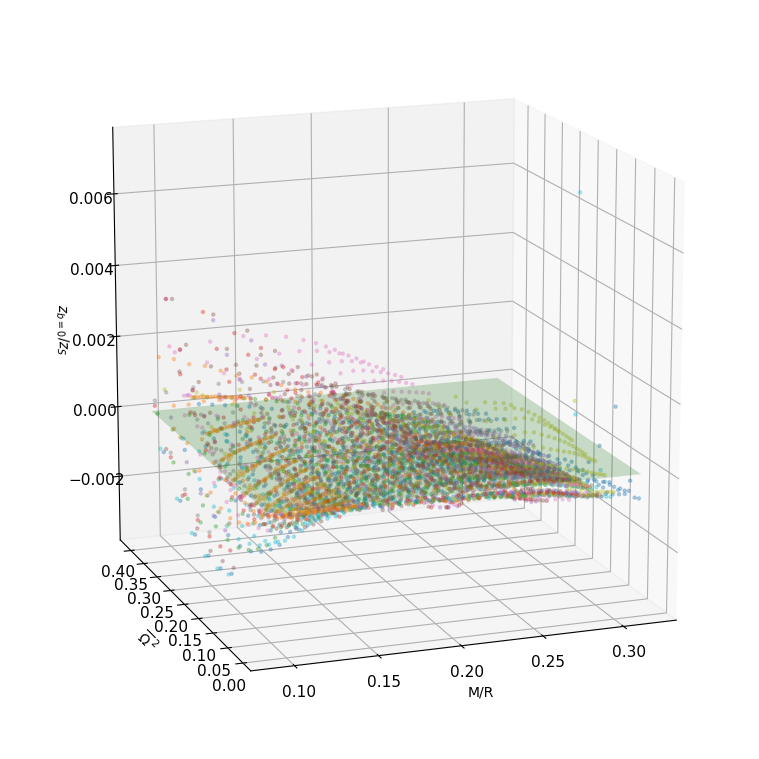

In [40]:
print(residual_objective([ 0.59659782,  0.63394646, -0.20057686,  1.46336219], Eos_array, create_fit_func([2,2])))
plot_3dredshifts(Eos_array, create_fit_func([2,2]), [ 0.59659782,  0.63394646, -0.20057686,  1.46336219])

8.900671815963371e-05


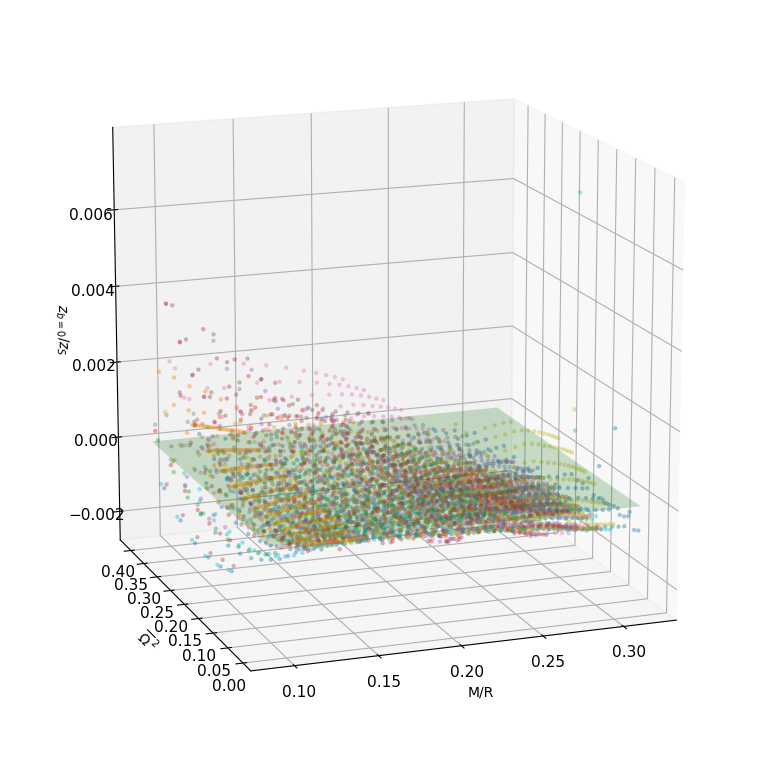

In [41]:
print(residual_objective([ 0.54446865,  1.14564791, -1.17334963, -0.08927648,  0.47259355,
        1.93766783], Eos_array, create_fit_func([2,3])))
plot_3dredshifts(Eos_array, create_fit_func([2,3]), [ 0.54446865,  1.14564791, -1.17334963, -0.08927648,  0.47259355,
        1.93766783])

8.900363615221496e-05


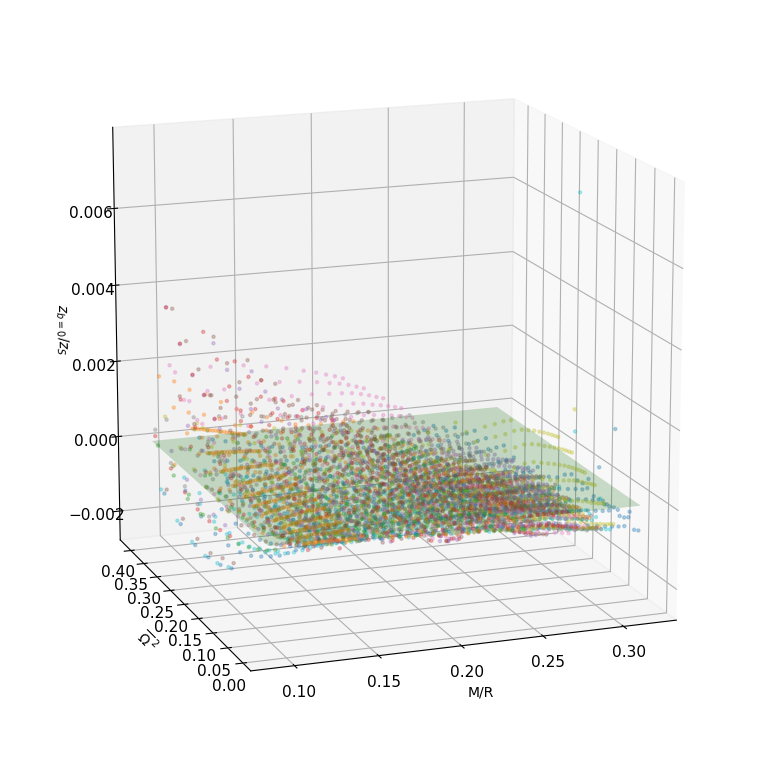

In [ ]:
print(residual_objective([ 0.53944633,  1.17920773, -1.20619338, -0.06465179,  0.34301731,
        1.874211  , -0.02449818,  0.08461446,  0.38444905], 
                    Eos_array, create_fit_func([3,3])))
plot_3dredshifts(Eos_array, create_fit_func([3,3]), [ 0.53944633,  1.17920773, -1.20619338, -0.06465179,  0.34301731,
        1.874211  , -0.02449818,  0.08461446,  0.38444905])

8.909040186295063e-05


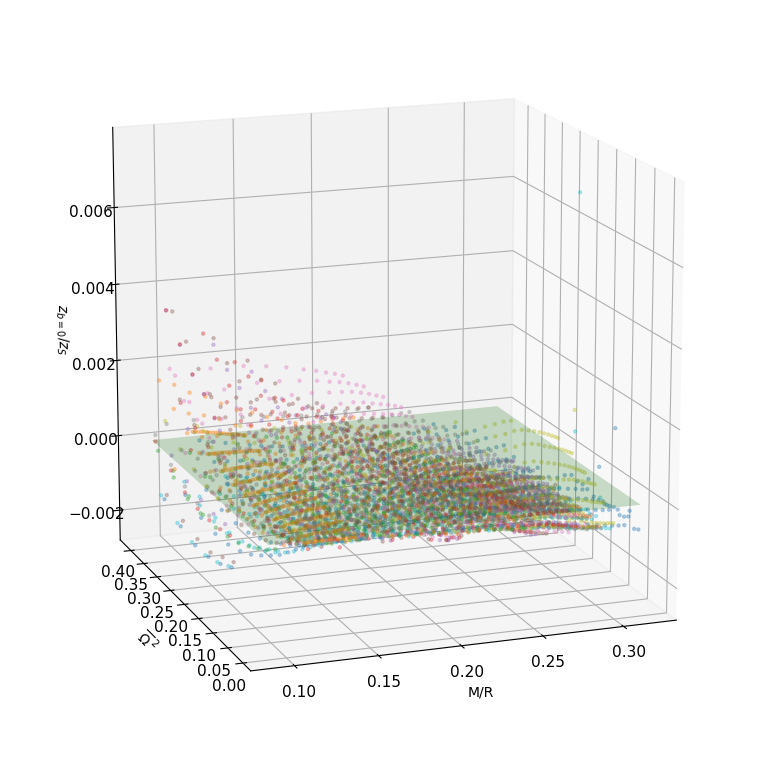

In [ ]:
print(residual_objective([ 0.54159666,  1.15752975, -1.16160173, -0.07811977,  0.4339902 ,
        1.84051189], Eos_array, create_fit_func([2,3])))
plot_3dredshifts(Eos_array, create_fit_func([2,3]), [ 0.54159666,  1.15752975, -1.16160173, -0.07811977,  0.4339902 ,
        1.84051189])

0.0011085140941321514


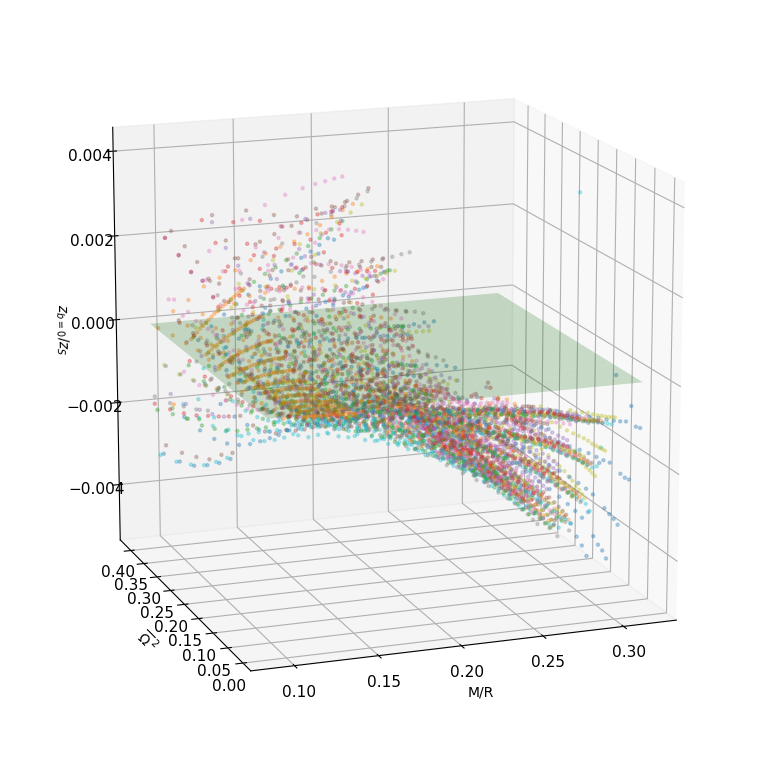

In [ ]:
print(residual_objective([0.53839792, 1.05210374], Eos_array, create_fit_func([1,2])))
plot_3dredshifts(Eos_array, create_fit_func([1,2]), [0.53839792, 1.05210374])

In [ ]:
print(residual_objective([0.53839792, 1.05210374], Eos_array, old_formula))
plot_3dredshifts(Eos_array, old_formula, [0.53839792, 1.05210374])

In [ ]:
def residual_objective_j(params, Eos_array, fit_func):

    M_R = np.empty([0])
    Js = np.empty([0])
    z_norm = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            js = eos.J(i_r)
            z_norm_p = (eos.z_rns(i_r)+1)*np.sqrt(1-2*mr)-1

            M_R = np.concatenate([M_R, mr])
            Js = np.concatenate([Js, js])
            z_norm = np.concatenate([z_norm, z_norm_p])

    z_emp = (fit_func(M_R, Js, params)+1)*np.sqrt(1-2*M_R)-1
    resid = np.sum((z_norm-z_emp)**2)

    return resid

In [ ]:
def diff_optimize_fit_j(shapes, bounds):

    lb = [bounds[0]]
    ub = [bounds[1]]
    lbs = lb*shapes[0]*shapes[1]
    #lbs[0] = 0.5439611
    #lbs[1] = 1.00764174
    ubs = ub*shapes[0]*shapes[1]
    #ubs[0] = 0.5439611
    #ubs[1] = 1.00764174
    bounds = Bounds(lbs, ubs)
    result = differential_evolution(residual_objective_j, bounds, args=(Eos_array, create_fit_func(shapes)))

    coeffs = result.x.reshape(shapes)
    row_label = ['\u03A9^'+str(2*(i+1)) for i in range(shapes[0])]
    col_label = ['M/R^'+str(i+1) for i in range(shapes[1])]
    table = pd.DataFrame(coeffs, index=row_label, columns=col_label)
    print(table)

    return result.x

In [ ]:
diff_optimize_fit_j([1,2], [-2,2])
print('\n')
diff_optimize_fit_j([2,2], [-4,4])
print('\n')

        M/R^1     M/R^2
Ω^2  0.665019  1.807269


        M/R^1     M/R^2
Ω^2  0.703445  1.379391
Ω^4 -0.484630  3.984746




In [ ]:
diff_optimize_fit_j([2,2], [-10,10])


        M/R^1     M/R^2
Ω^2  0.699585  1.398344
Ω^4 -0.462223  3.869146


array([ 0.69958524,  1.39834377, -0.46222329,  3.86914604])

In [ ]:
residual_objective_j([0.664825,  1.808241], Eos_array, create_fit_func([1,2]))

0.008016788882993637

In [ ]:
def plot_3dredshifts_j(Eos_array, fit_func, params):

    fig = plt.figure(figsize=plt.figaspect(0.9)*2)
    ax = fig.add_subplot(projection='3d')

    M_R = np.empty([0])
    Js = np.empty([0])
    z_norm = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            js = eos.J(i_r)
            z_norm_p = (eos.z_rns(i_r))#+1)*np.sqrt(1-2*mr)-1
            z_emp_p = (fit_func(mr, js, params))#+1)*np.sqrt(1-2*mr)-1

            ax.scatter(mr, js**2, (z_norm_p-z_emp_p)/z_emp_p, alpha=0.3, s=5)

            M_R = np.concatenate([M_R, mr])
            Js = np.concatenate([Js, js])
            z_norm = np.concatenate([z_norm, z_norm_p])

    M_R_mesh, spins_mesh = np.meshgrid(np.sort(M_R), np.sort(Js))
    z_emp = (fit_func(M_R_mesh, spins_mesh, params)+1)*np.sqrt(1-2*M_R_mesh)-1

    #ax.plot_surface(M_R_mesh, spins_mesh**2, z_emp, color='green', alpha=0.2)
    ax.plot_surface(M_R_mesh, spins_mesh**2, np.zeros(M_R_mesh.shape), color='green', alpha=0.2)
    ax.view_init(elev=15, azim=-110)
    ax.set_box_aspect(aspect=(1, 1, 1))
    font=11
    ax.tick_params(labelsize=font, pad=1)
    ax.tick_params(axis='z', labelsize=font, pad=4)
    ax.set_xlabel("M/R", labelpad=2)
    ax.set_ylabel("$\overline{\Omega}^{\ 2}$", labelpad=2)
    ax.set_zlabel("$z_{b=0}/z_S$", labelpad=8)

    #plt.savefig("3d_z.png", dpi=390)

0.008016788882993637


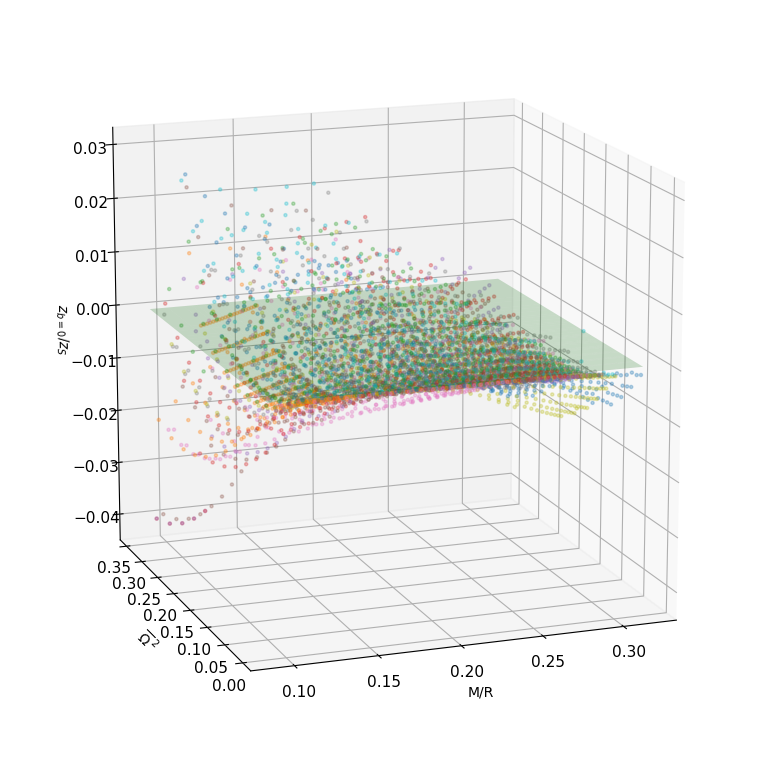

In [ ]:
print(residual_objective_j([0.664825,  1.808241], Eos_array, create_fit_func([1,2])))
plot_3dredshifts_j(Eos_array, create_fit_func([1,2]), [0.664825,  1.808241])

0.006904349325068092


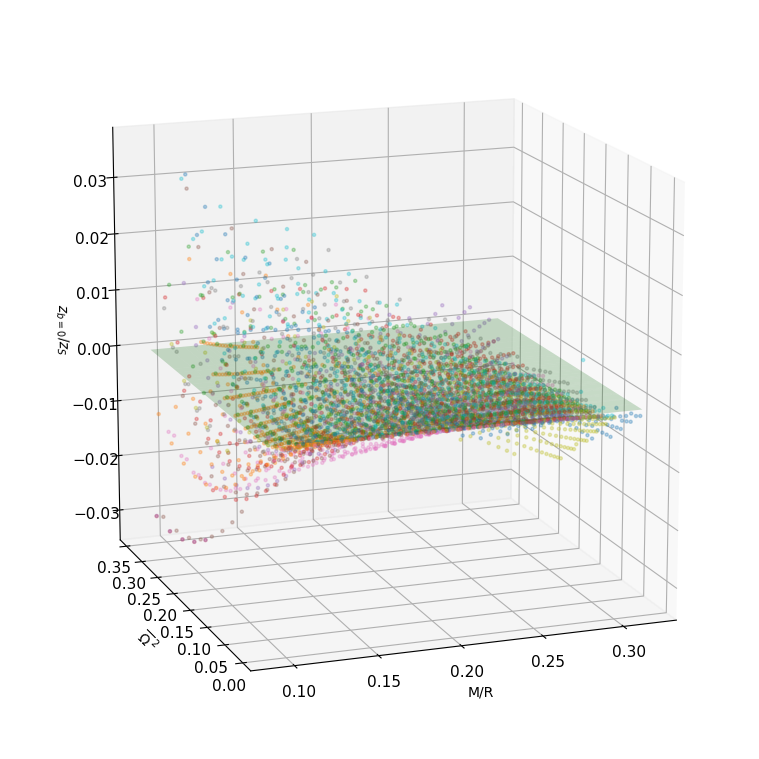

In [ ]:
print(residual_objective_j([ 0.69958524,  1.39834377, -0.46222329,  3.86914604], Eos_array, create_fit_func([2,2])))
plot_3dredshifts_j(Eos_array, create_fit_func([2,2]), [ 0.69958524,  1.39834377, -0.46222329,  3.86914604])

In [ ]:
def create_dataset(i):
    
    eos = eos_names[i]
    e_min = min_dens[i]
    e_max = max_dens[i]
    ratios = r_ratios
    densities = np.linspace(e_min, e_max, N_dens)

    star_data = np.zeros([N_dens, N_spins, 11])
    i_r=0
    t_0 = time.time()
    for r in ratios:
        i_e = 0
        for e in densities:
            string = 'quasik.exe -f "../compose/eos' + eos + '" -e ' + "{:e}".format(e).replace('+', '') + ' -r ' + str(r)
            sub.run(string)
            output = np.loadtxt('star.csv', delimiter=',')
            star_data[i_e,i_r,:] = output
            print(eos+'  %i, %i ' % (i_r+1, i_e+1), end='\r')
            i_e += 1
        i_r += 1
    np.save('star_data_'+eos, star_data)
    t_f = time.time()
    t_min = round((t_f-t_0)/60, 2)
    print(eos+' done in '+str(t_min)+' minutes')
    return

In [ ]:
for i in range(eos_names.size):
    try:
        create_dataset(i)
    except ValueError:
        print(str(eos_names[i])+' failed due to ValueError')
    except TypeError:
        print(str(eos_names[i])+' failed due to TypeError')
    except Exception:
        print(str(eos_names[i])+' failed due to Exception')